# Async bulk ingestion → SQLite

This notebook visualises data ingested by [`scripts/hydrometrie/bulk_ingest.py`](../scripts/hydrometrie/bulk_ingest.py).

The script:
1. Discovers active hydrometric stations in a French department
2. Fetches 7 days of flow rate observations **concurrently** via `asyncio.gather` and `AsyncHubeauClient`
3. Ingests results into a local SQLite database

Run the script first:
```bash
uv run python scripts/hydrometrie/bulk_ingest.py
```

> **Why async?** Hub'Eau has no bulk endpoint — each station requires its own HTTP request.
> `asyncio.gather` sends all requests concurrently and collects responses as they arrive,
> cutting wall time by ~N× compared to sequential fetching.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = Path("../data/hydrometrie/observations.db")
DEPARTMENT = "64"
WINDOW_DAYS = 7

## Load from SQLite

In [2]:
con = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM observations ORDER BY code_station, date_obs", con)
con.close()

df["date_obs"] = pd.to_datetime(df["date_obs"])
print(f"{len(df)} rows, {df['code_station'].nunique()} stations")
df.head()

7323 rows, 5 stations


,code_station,libelle_station,date_obs,resultat_obs,grandeur_hydro
0,Q132401001,Le Gabas à Poursiugues-Boucoue,2026-06-07 10:15:00+00:00,470.0,Q
1,Q132401001,Le Gabas à Poursiugues-Boucoue,2026-06-07 10:30:00+00:00,463.0,Q
2,Q132401001,Le Gabas à Poursiugues-Boucoue,2026-06-07 10:45:00+00:00,460.0,Q
3,Q132401001,Le Gabas à Poursiugues-Boucoue,2026-06-07 11:00:00+00:00,453.0,Q
4,Q132401001,Le Gabas à Poursiugues-Boucoue,2026-06-07 11:15:00+00:00,449.0,Q


## Plot — all stations

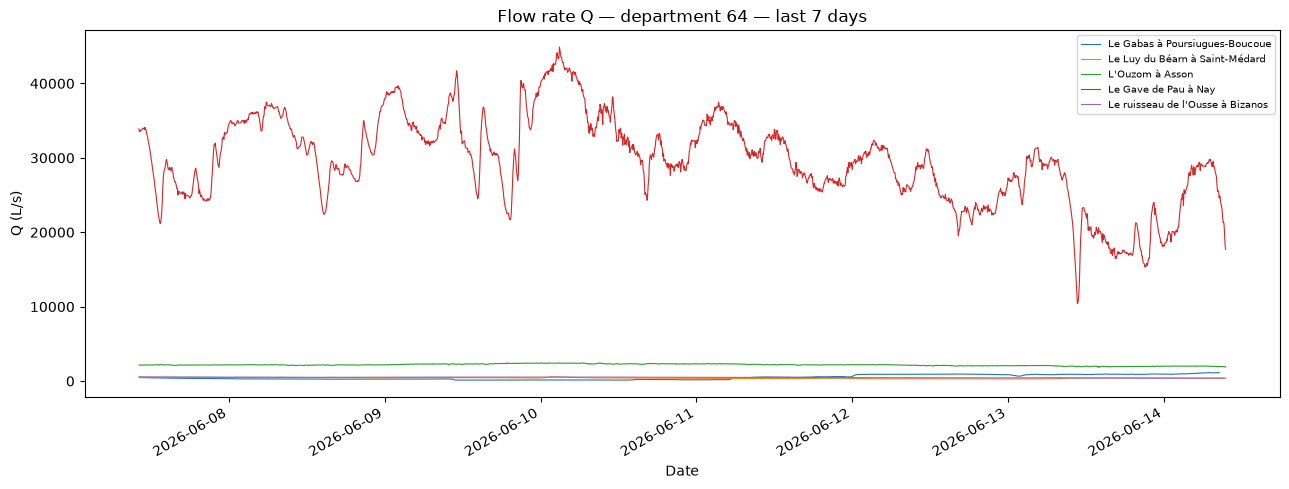

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

for code, group in df.groupby("code_station"):
    label = group["libelle_station"].iloc[0]
    ax.plot(group["date_obs"], group["resultat_obs"], linewidth=0.8, label=label)

ax.set_title(
    f"Flow rate Q — department {DEPARTMENT} — last {WINDOW_DAYS} days"
)
ax.set_xlabel("Date")
ax.set_ylabel("Q (L/s)")
ax.legend(fontsize=7, loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

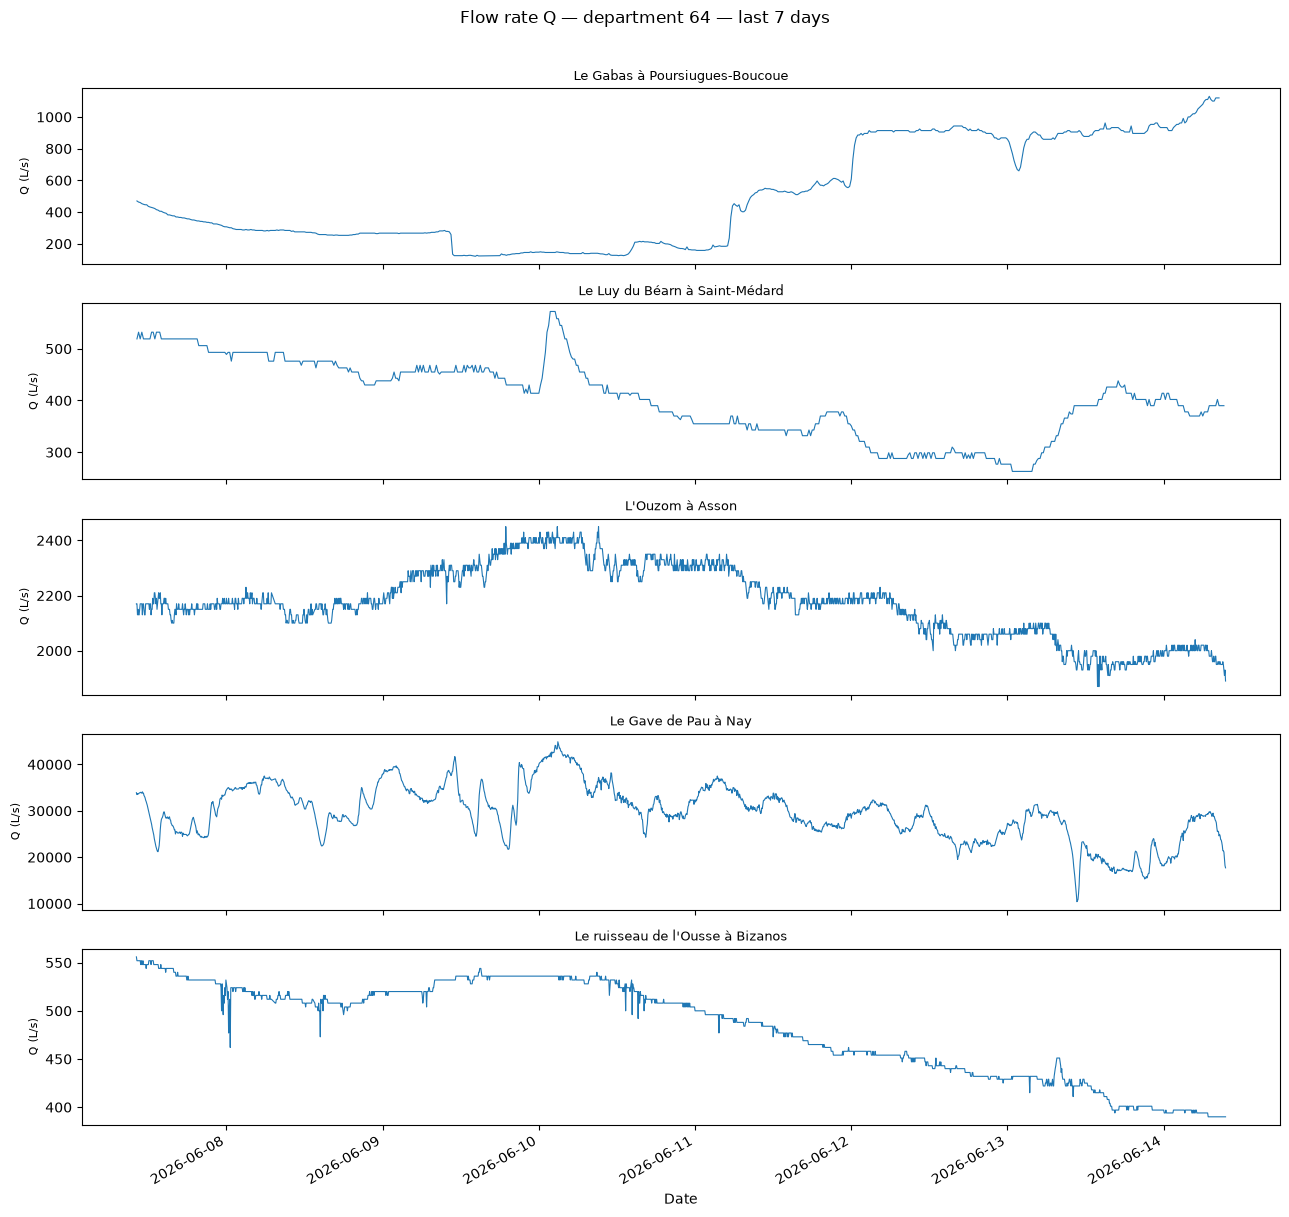

In [4]:
fig, axes = plt.subplots(len(df["code_station"].unique()), 1, figsize=(13, 12), sharex=True)

for ax, (code, group) in zip(axes, df.groupby("code_station")):
    label = group["libelle_station"].iloc[0]
    ax.plot(group["date_obs"], group["resultat_obs"], linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Q (L/s)", fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Flow rate Q — department {DEPARTMENT} — last {WINDOW_DAYS} days", y=1.01)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()